# BookAI - Sistema Inteligente de Recomendación de Libros

**Feature**: 001-book-recommendations  
**Dataset**: Best Selling Books 2023-2025  
**Enfoque**: Content-based recommendations usando embeddings + LLM reasoning

## Arquitectura
1. **Carga y exploración de datos**
2. **Preprocesamiento y limpieza**
3. **Generación de embeddings** (sentence-transformers)
4. **Sistema de búsqueda por similitud** (cosine similarity)
5. **Motor de recomendaciones** (P1: género, P2: similitud, P3: preferencias)
6. **Integración LLM** (P4: explicaciones y refinamiento)

## 1. Setup e Importaciones

In [ ]:
# Instalación de dependencias (ejecutar solo una vez)
# !pip install pandas numpy scikit-learn anthropic openai python-dotenv

In [ ]:
import pandas as pd
import numpy as np
import re
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Embeddings y similitud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# LLM integration (opcional - descomentar si se usa)
# from anthropic import Anthropic
# from openai import OpenAI
# from dotenv import load_dotenv
# import os
# load_dotenv()

print("✅ Librerías importadas correctamente")

## 2. Carga y Exploración de Datos

In [9]:
# Cargar dataset
df = pd.read_csv('best sellin books total.csv', encoding="latin-1")

print(f"📚 Dataset cargado: {df.shape[0]} libros")
print(f"📊 Columnas: {df.columns.tolist()}")
print(f"\n🔍 Primeras filas:")
df.head()

📚 Dataset cargado: 210 libros
📊 Columnas: ['Book name', 'Author', 'Rating', 'reviews count', 'form', 'price', 'Reading age', 'Print Length', 'Publishing date', 'Genre', 'id_2023', 'id_2024', 'id_2025']

🔍 Primeras filas:


,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
0,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$18.88,NaN,320.0,16/10/2018,Self-Improvement,#1,#3,#6
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$11.05,NaN,640.0,07/11/2023,Fiction & Action & Adventure,#2,#13,NaN
2,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$11.99,NaN,416.0,"January 10, 2023",Biographies & Memoirs,#3,NaN,NaN
3,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$13.62,NaN,544.0,17/09/2024,Fiction & Action & Adventure,#4,#16,#76
4,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$11.37,NaN,288.0,"October 24, 2023",Biographies & Memoirs,#5,NaN,NaN


In [10]:
# Información del dataset
print("📈 Información del dataset:")
df.info()
print("\n📊 Estadísticas descriptivas:")
df.describe(include='all')

📈 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Book name        210 non-null    object 
 1   Author           210 non-null    object 
 2   Rating           210 non-null    object 
 3   reviews count    210 non-null    int64  
 4   form             210 non-null    object 
 5   price            210 non-null    object 
 6   Reading age      71 non-null     object 
 7   Print Length     208 non-null    float64
 8   Publishing date  210 non-null    object 
 9   Genre            210 non-null    object 
 10  id_2023          100 non-null    object 
 11  id_2024          110 non-null    object 
 12  id_2025          98 non-null     object 
dtypes: float64(1), int64(1), object(11)
memory usage: 21.5+ KB

📊 Estadísticas descriptivas:


,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
count,210,210,210,210.000000,210,210,71,208.000000,210,210,100,110,98
unique,196,153,9,NaN,6,168,18,NaN,176,21,100,100,98
top,"Dad, I Want to Hear Your Story: A Fathers Gui...",Sarah J. Maas,4.8 out of 5 stars,NaN,Paperback,$9.99,1 - 2 years,NaN,02/06/2020,Fiction & Action & Adventure,#1,#32,#6
freq,2,10,54,NaN,106,8,10,NaN,7,55,1,2,1
mean,NaN,NaN,NaN,90436.204762,NaN,NaN,NaN,337.139423,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,115795.102175,NaN,NaN,NaN,294.944529,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,476.000000,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,13721.750000,NaN,NaN,NaN,143.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,40693.500000,NaN,NaN,NaN,320.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,115439.250000,NaN,NaN,NaN,432.000000,NaN,NaN,NaN,NaN,NaN


In [11]:
# Análisis de valores nulos
print("🔍 Valores nulos por columna:")
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
pd.DataFrame({
    'Nulos': null_counts,
    'Porcentaje': null_pct
}).sort_values('Nulos', ascending=False)

🔍 Valores nulos por columna:


,Nulos,Porcentaje
Reading age,139,66.19
id_2025,112,53.33
id_2023,110,52.38
id_2024,100,47.62
Print Length,2,0.95
Book name,0,0.00
Author,0,0.00
Rating,0,0.00
reviews count,0,0.00
form,0,0.00


📚 Distribución de géneros:

Total de géneros únicos: 43

Top 10 géneros:
Action         55
Adventure      55
Fiction        55
Reading        37
Writing        37
Photography    18
Music          18
Arts           18
Mystery        17
Thriller       17
Name: count, dtype: int64


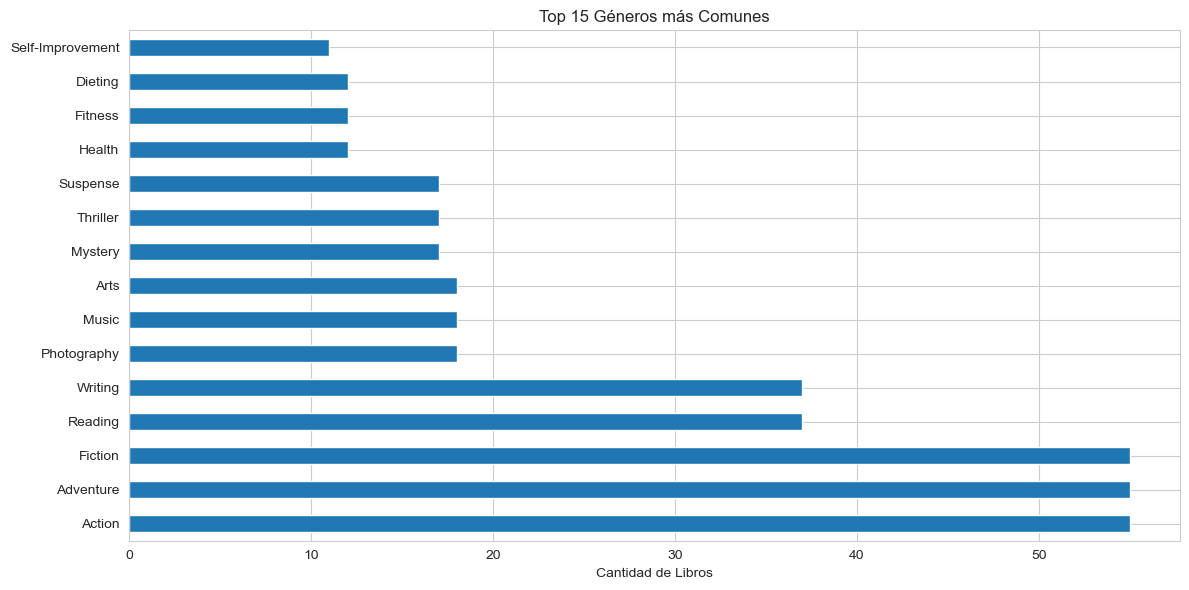

In [14]:
# Análisis de géneros
print("📚 Distribución de géneros:")
all_genres = []
for genres in df['Genre'].dropna():
    all_genres.extend([g.strip() for g in str(genres).split('&')])

genre_counts = pd.Series(all_genres).value_counts()
print(f"\nTotal de géneros únicos: {len(genre_counts)}")
print(f"\nTop 10 géneros:")
print(genre_counts.head(10))

# Visualización
plt.figure(figsize=(12, 6))
genre_counts.head(15).plot(kind='barh')
plt.title('Top 15 Géneros más Comunes')
plt.xlabel('Cantidad de Libros')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento y Limpieza

In [15]:
def clean_rating(rating_str):
    """Extrae el valor numérico del rating (ej: '4.8 out of 5 stars' -> 4.8)"""
    if pd.isna(rating_str):
        return None
    match = re.search(r'(\d+\.\d+)', str(rating_str))
    return float(match.group(1)) if match else None

def clean_price(price_str):
    """Extrae el valor numérico del precio (ej: '$18.88' -> 18.88)"""
    if pd.isna(price_str):
        return None
    match = re.search(r'\$(\d+\.\d+)', str(price_str))
    return float(match.group(1)) if match else None

def clean_reviews_count(reviews_str):
    """Convierte reviews count a entero"""
    if pd.isna(reviews_str):
        return 0
    return int(str(reviews_str).replace(',', ''))

def parse_genres(genre_str):
    """Divide géneros múltiples en lista"""
    if pd.isna(genre_str):
        return []
    return [g.strip() for g in str(genre_str).split('&')]

# Aplicar limpieza
print("🧹 Limpiando datos...")
df['rating_clean'] = df['Rating'].apply(clean_rating)
df['price_clean'] = df['price'].apply(clean_price)
df['reviews_count_clean'] = df['reviews count'].apply(clean_reviews_count)
df['genres_list'] = df['Genre'].apply(parse_genres)
df['primary_genre'] = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')

# Crear columna de año de publicación
df['pub_year'] = pd.to_datetime(df['Publishing date'], errors='coerce').dt.year

print("✅ Datos limpios")
print(f"\n📊 Estadísticas post-limpieza:")
df[['rating_clean', 'price_clean', 'reviews_count_clean', 'Print Length', 'pub_year']].describe()

🧹 Limpiando datos...
✅ Datos limpios

📊 Estadísticas post-limpieza:


,rating_clean,price_clean,reviews_count_clean,Print Length,pub_year
count,210.000000,210.000000,210.000000,208.000000,152.000000
mean,4.657143,11.849762,90436.204762,337.139423,2017.756579
std,0.181623,7.193753,115795.102175,294.944529,10.655345
min,4.100000,1.000000,476.000000,12.000000,1959.000000
25%,4.600000,7.977500,13721.750000,143.000000,2016.000000
50%,4.700000,10.205000,40693.500000,320.000000,2021.000000
75%,4.800000,14.112500,115439.250000,432.000000,2024.000000
max,4.900000,52.620000,653111.000000,2896.000000,2025.000000


In [16]:
# Crear texto descriptivo para embeddings
def create_book_description(row):
    """Crea un texto descriptivo combinando título, autor y género para embeddings"""
    parts = [
        f"Title: {row['Book name']}",
        f"Author: {row['Author']}",
        f"Genre: {row['Genre']}" if pd.notna(row['Genre']) else ""
    ]
    return " | ".join([p for p in parts if p])

df['book_description'] = df.apply(create_book_description, axis=1)

print("✅ Descripciones de libros creadas")
print("\n📝 Ejemplo de descripción:")
print(df['book_description'].iloc[0])

✅ Descripciones de libros creadas

📝 Ejemplo de descripción:
Title: Atomic Habits: An Easy & Proven Way to Build Good Habits & Break Bad Ones | Author: James Clear | Genre: Self-Improvement


## 4. Generación de Embeddings

Usamos **TF-IDF** (Term Frequency-Inverse Document Frequency) de scikit-learn para generar representaciones vectoriales de cada libro basadas en palabras clave del título, autor y género.

In [ ]:
# Crear y entrenar el vectorizador TF-IDF
print("🤖 Creando vectorizador TF-IDF...")

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigramas y bigramas
    min_df=1,
    max_features=5000,
    sublinear_tf=True
)

# Entrenar sobre todas las descripciones de libros
vectorizer.fit(df['book_description'].tolist())

vocab_size = len(vectorizer.vocabulary_)
print(f"✅ Vectorizador entrenado: {vocab_size} términos en vocabulario")

In [ ]:
# Generar vectores TF-IDF para todos los libros
print("🔄 Generando vectores TF-IDF para todos los libros...")

book_embeddings = vectorizer.transform(df['book_description'].tolist()).toarray()

# Normalizar para cosine similarity eficiente
book_embeddings_normalized = normalize(book_embeddings)

print(f"✅ Vectores generados: {book_embeddings.shape}")
print(f"📊 Tamaño en memoria: {book_embeddings.nbytes / 1024 / 1024:.2f} MB")

In [ ]:
# Guardar embeddings para reutilización (opcional)
# np.save('book_embeddings.npy', book_embeddings)
# print("💾 Embeddings guardados en 'book_embeddings.npy'")

## 5. Sistema de Recomendaciones

### 5.1 P1: Recomendaciones Básicas por Género

In [ ]:
def recommend_by_genre(
    genre_query: str,
    top_k: int = 10,
    min_rating: float = 4.0
) -> pd.DataFrame:
    """
    P1: Recomendaciones básicas por género usando vectores TF-IDF.
    
    Args:
        genre_query: Género o interés del usuario (ej: "Mystery", "Science Fiction")
        top_k: Número de recomendaciones a devolver
        min_rating: Rating mínimo para filtrar
    
    Returns:
        DataFrame con las top_k recomendaciones
    """
    # Generar vector TF-IDF de la consulta
    query_embedding = vectorizer.transform([f"Genre: {genre_query}"]).toarray()
    query_embedding_normalized = normalize(query_embedding)
    
    # Calcular similitud con todos los libros
    similarities = cosine_similarity(query_embedding_normalized, book_embeddings_normalized)[0]
    
    # Agregar similitud al dataframe
    df_temp = df.copy()
    df_temp['similarity'] = similarities
    
    # Filtrar por rating mínimo
    df_temp = df_temp[df_temp['rating_clean'] >= min_rating]
    
    # Ordenar por similitud y devolver top_k
    recommendations = df_temp.nlargest(top_k, 'similarity')
    
    return recommendations[[
        'Book name', 'Author', 'Genre', 'rating_clean', 
        'price_clean', 'Print Length', 'similarity'
    ]]

# Ejemplo de uso
print("🔍 Ejemplo P1: Recomendaciones de 'Science Fiction'\n")
recs = recommend_by_genre("Science Fiction", top_k=5)
for idx, row in recs.iterrows():
    print(f"📚 {row['Book name']}")
    print(f"   ✍️  {row['Author']}")
    print(f"   🎭 {row['Genre']}")
    print(f"   ⭐ {row['rating_clean']:.1f} | 💰 ${row['price_clean']:.2f} | 📄 {row['Print Length']} páginas")
    print(f"   🎯 Similitud: {row['similarity']:.3f}")
    print()

### 5.2 P2: Búsqueda por Similitud (Libros Similares)

In [ ]:
def recommend_similar_books(
    book_title: str,
    top_k: int = 10,
    exclude_same_author: bool = False
) -> pd.DataFrame:
    """
    P2: Encuentra libros similares a un libro dado.
    
    Args:
        book_title: Título del libro de referencia
        top_k: Número de recomendaciones
        exclude_same_author: Si True, excluye libros del mismo autor
    
    Returns:
        DataFrame con libros similares
    """
    # Buscar el libro en el dataset (búsqueda flexible)
    matches = df[df['Book name'].str.contains(book_title, case=False, na=False)]
    
    if len(matches) == 0:
        print(f"❌ Libro '{book_title}' no encontrado")
        return pd.DataFrame()
    
    # Usar el primer match
    book_idx = matches.index[0]
    book_embedding = book_embeddings_normalized[book_idx].reshape(1, -1)
    book_author = df.iloc[book_idx]['Author']
    
    print(f"✅ Libro encontrado: {df.iloc[book_idx]['Book name']}")
    print(f"   Autor: {book_author}\n")
    
    # Calcular similitud con todos los libros
    similarities = cosine_similarity(book_embedding, book_embeddings_normalized)[0]
    
    df_temp = df.copy()
    df_temp['similarity'] = similarities
    
    # Excluir el libro original
    df_temp = df_temp.drop(book_idx)
    
    # Opcionalmente excluir mismo autor
    if exclude_same_author:
        df_temp = df_temp[df_temp['Author'] != book_author]
    
    recommendations = df_temp.nlargest(top_k, 'similarity')
    
    return recommendations[[
        'Book name', 'Author', 'Genre', 'rating_clean',
        'price_clean', 'similarity'
    ]]

# Ejemplo de uso
print("🔍 Ejemplo P2: Libros similares a 'Atomic Habits'\n")
similar = recommend_similar_books("Atomic Habits", top_k=5)
for idx, row in similar.iterrows():
    print(f"📚 {row['Book name']}")
    print(f"   ✍️  {row['Author']}")
    print(f"   🎭 {row['Genre']}")
    print(f"   ⭐ {row['rating_clean']:.1f} | 💰 ${row['price_clean']:.2f}")
    print(f"   🎯 Similitud: {row['similarity']:.3f}")
    print()

### 5.3 P3: Recomendaciones Personalizadas con Preferencias

In [ ]:
def recommend_personalized(
    preferences: Dict[str, any],
    top_k: int = 10
) -> pd.DataFrame:
    """
    P3: Recomendaciones personalizadas basadas en preferencias detalladas.
    
    Args:
        preferences: Dict con claves como:
            - 'favorite_authors': List[str]
            - 'favorite_genres': List[str]
            - 'disliked_genres': List[str]
            - 'max_price': float
            - 'min_rating': float
            - 'max_length': int (páginas)
            - 'min_length': int (páginas)
        top_k: Número de recomendaciones
    
    Returns:
        DataFrame con recomendaciones personalizadas
    """
    # Crear query semántica a partir de preferencias
    query_parts = []
    
    if 'favorite_authors' in preferences:
        query_parts.append(f"Authors like {', '.join(preferences['favorite_authors'])}")
    
    if 'favorite_genres' in preferences:
        query_parts.append(f"Genres: {', '.join(preferences['favorite_genres'])}")
    
    query_text = " | ".join(query_parts) if query_parts else "Books"
    
    # Generar vector TF-IDF de la consulta
    query_embedding = vectorizer.transform([query_text]).toarray()
    query_embedding_normalized = normalize(query_embedding)
    
    # Calcular similitud
    similarities = cosine_similarity(query_embedding_normalized, book_embeddings_normalized)[0]
    
    df_temp = df.copy()
    df_temp['similarity'] = similarities
    
    # Aplicar filtros
    if 'max_price' in preferences:
        df_temp = df_temp[df_temp['price_clean'] <= preferences['max_price']]
    
    if 'min_rating' in preferences:
        df_temp = df_temp[df_temp['rating_clean'] >= preferences['min_rating']]
    
    if 'max_length' in preferences:
        df_temp = df_temp[df_temp['Print Length'] <= preferences['max_length']]
    
    if 'min_length' in preferences:
        df_temp = df_temp[df_temp['Print Length'] >= preferences['min_length']]
    
    # Excluir géneros no deseados
    if 'disliked_genres' in preferences:
        for genre in preferences['disliked_genres']:
            df_temp = df_temp[~df_temp['Genre'].str.contains(genre, case=False, na=False)]
    
    # Bonus: dar peso extra a autores favoritos
    if 'favorite_authors' in preferences:
        for author in preferences['favorite_authors']:
            mask = df_temp['Author'].str.contains(author, case=False, na=False)
            df_temp.loc[mask, 'similarity'] *= 1.2  # Boost 20%
    
    recommendations = df_temp.nlargest(top_k, 'similarity')
    
    return recommendations[[
        'Book name', 'Author', 'Genre', 'rating_clean',
        'price_clean', 'Print Length', 'similarity'
    ]]

# Ejemplo de uso
print("🔍 Ejemplo P3: Recomendaciones personalizadas\n")
user_prefs = {
    'favorite_authors': ['James Clear', 'Malcolm Gladwell'],
    'favorite_genres': ['Self-Improvement', 'Business'],
    'disliked_genres': ['Romance'],
    'max_price': 25.0,
    'min_rating': 4.5,
    'max_length': 400
}

print("👤 Preferencias del usuario:")
for key, value in user_prefs.items():
    print(f"   • {key}: {value}")
print()

personalized = recommend_personalized(user_prefs, top_k=5)
for idx, row in personalized.iterrows():
    print(f"📚 {row['Book name']}")
    print(f"   ✍️  {row['Author']}")
    print(f"   🎭 {row['Genre']}")
    print(f"   ⭐ {row['rating_clean']:.1f} | 💰 ${row['price_clean']:.2f} | 📄 {row['Print Length']} páginas")
    print(f"   🎯 Similitud: {row['similarity']:.3f}")
    print()

### 5.4 P4: Explicaciones con LLM (Preparado para Claude/OpenAI)

In [ ]:
# Descomentar y configurar según el LLM que uses

# # Opción 1: Claude (Anthropic)
# client = Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY'))

# # Opción 2: OpenAI
# client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

def generate_recommendation_explanation(
    book: pd.Series,
    user_query: str,
    use_llm: bool = False
) -> str:
    """
    P4: Genera explicación de por qué se recomienda un libro.
    
    Args:
        book: Serie de pandas con datos del libro
        user_query: Query original del usuario
        use_llm: Si True, usa LLM; si False, usa template simple
    
    Returns:
        Explicación en texto
    """
    if not use_llm:
        # Explicación simple basada en reglas (fallback)
        explanation = f"Este libro coincide con tu búsqueda de '{user_query}'. "
        explanation += f"Es un libro de {book['Genre']} escrito por {book['Author']}. "
        explanation += f"Tiene un rating de {book['rating_clean']:.1f}/5.0 basado en {book['reviews_count_clean']:,} reviews."
        return explanation
    
    # TODO: Implementar llamada a LLM
    # Ejemplo con Claude:
    """
    prompt = f"""
    El usuario buscó: "{user_query}"
    
    Libro recomendado:
    - Título: {book['Book name']}
    - Autor: {book['Author']}
    - Género: {book['Genre']}
    - Rating: {book['rating_clean']}/5.0
    - Precio: ${book['price_clean']}
    
    Genera una explicación breve (2-3 frases) de por qué este libro es una buena recomendación para el usuario.
    """
    
    response = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=150,
        messages=[{"role": "user", "content": prompt}]
    )
    
    return response.content[0].text
    """
    
    return "[LLM no configurado - usar use_llm=False para explicación simple]"

# Ejemplo de uso
print("🤖 Ejemplo P4: Explicaciones de recomendaciones\n")
sample_book = df.iloc[0]
explanation = generate_recommendation_explanation(
    sample_book,
    "Self-improvement books",
    use_llm=False  # Cambiar a True cuando LLM esté configurado
)
print(f"📚 {sample_book['Book name']}")
print(f"\n💡 Explicación:")
print(f"   {explanation}")

## 6. Evaluación y Métricas

In [ ]:
import time

def evaluate_performance():
    """Evalúa el tiempo de respuesta del sistema (SC-001: <1s)"""
    
    test_queries = [
        "Science Fiction",
        "Business books",
        "Historical Fiction",
        "Self-Improvement",
        "Mystery and Thriller"
    ]
    
    times = []
    
    print("⏱️ Evaluando performance del sistema...\n")
    
    for query in test_queries:
        start = time.time()
        _ = recommend_by_genre(query, top_k=10)
        elapsed = time.time() - start
        times.append(elapsed)
        
        status = "✅" if elapsed < 1.0 else "⚠️"
        print(f"{status} Query: '{query}' | Tiempo: {elapsed:.3f}s")
    
    avg_time = np.mean(times)
    pct_under_1s = (np.array(times) < 1.0).sum() / len(times) * 100
    
    print(f"\n📊 Resultados:")
    print(f"   • Tiempo promedio: {avg_time:.3f}s")
    print(f"   • Tiempo mínimo: {min(times):.3f}s")
    print(f"   • Tiempo máximo: {max(times):.3f}s")
    print(f"   • Consultas <1s: {pct_under_1s:.1f}%")
    
    if pct_under_1s >= 95:
        print(f"\n✅ SC-001 PASSED: {pct_under_1s:.1f}% >= 95% target")
    else:
        print(f"\n❌ SC-001 FAILED: {pct_under_1s:.1f}% < 95% target")

evaluate_performance()

In [ ]:
def evaluate_relevance():
    """Evalúa la relevancia de las recomendaciones (SC-002: 80% relevancia)"""
    
    test_cases = [
        {"query": "Science Fiction", "expected_genre": "Fiction"},
        {"query": "Self-Improvement", "expected_genre": "Self-Improvement"},
        {"query": "Business", "expected_genre": "Business"},
        {"query": "Mystery", "expected_genre": "Mystery"},
    ]
    
    print("🎯 Evaluando relevancia de recomendaciones...\n")
    
    total_relevant = 0
    total_recs = 0
    
    for test in test_cases:
        recs = recommend_by_genre(test['query'], top_k=10)
        
        # Contar cuántas recomendaciones contienen el género esperado
        relevant = recs['Genre'].str.contains(test['expected_genre'], case=False, na=False).sum()
        total = len(recs)
        
        relevance_pct = (relevant / total * 100) if total > 0 else 0
        
        total_relevant += relevant
        total_recs += total
        
        status = "✅" if relevance_pct >= 80 else "⚠️"
        print(f"{status} Query: '{test['query']}' | Relevancia: {relevance_pct:.1f}% ({relevant}/{total})")
    
    overall_relevance = (total_relevant / total_recs * 100) if total_recs > 0 else 0
    
    print(f"\n📊 Relevancia general: {overall_relevance:.1f}%")
    
    if overall_relevance >= 80:
        print(f"✅ SC-002 PASSED: {overall_relevance:.1f}% >= 80% target")
    else:
        print(f"❌ SC-002 FAILED: {overall_relevance:.1f}% < 80% target")

evaluate_relevance()

## 7. Sistema de Recomendación Completo (API-Ready)

In [ ]:
class BookRecommender:
    """
    Sistema completo de recomendaciones de libros.
    Encapsula toda la funcionalidad en una clase reutilizable.
    """
    
    def __init__(self, df: pd.DataFrame, embeddings: np.ndarray, vectorizer):
        self.df = df.reset_index(drop=True)  # Garantiza índice 0..N-1
        self.embeddings = normalize(embeddings)
        self.vectorizer = vectorizer
        print("✅ BookRecommender inicializado")
        print(f"   📚 {len(self.df)} libros en catálogo")
        print(f"   🎯 {embeddings.shape[1]} dimensiones de vector")
    
    def search(self, query: str) -> pd.DataFrame:
        """Busca títulos en el catálogo que contengan la query."""
        matches = self.df[self.df['Book name'].str.contains(query, case=False, na=False)]
        if len(matches) == 0:
            print(f"❌ Ningún título contiene '{query}'")
        return matches[['Book name', 'Author', 'Genre']].reset_index(drop=True)

    def recommend(
        self,
        query: str = None,
        book_title: str = None,
        preferences: Dict = None,
        top_k: int = 10,
        min_rating: float = 0.0
    ) -> Tuple[pd.DataFrame, str]:
        """
        Punto de entrada unificado para recomendaciones.
        
        Args:
            query: Búsqueda por género o interés (P1)
            book_title: Búsqueda por similitud a un libro (P2)
            preferences: Dict con preferencias detalladas (P3)
            top_k: Número de recomendaciones
            min_rating: Rating mínimo
        
        Returns:
            (DataFrame con recomendaciones, tipo de recomendación)
        """
        if book_title:
            return self._recommend_by_similarity(book_title, top_k), "similarity"
        elif preferences:
            return self._recommend_personalized(preferences, top_k), "personalized"
        elif query:
            return self._recommend_by_genre(query, top_k, min_rating), "genre"
        else:
            raise ValueError("Debe proporcionar query, book_title o preferences")
    
    def _recommend_by_genre(self, query: str, top_k: int, min_rating: float):
        query_embedding = self.vectorizer.transform([f"Genre: {query}"]).toarray()
        query_embedding = normalize(query_embedding)
        similarities = cosine_similarity(query_embedding, self.embeddings)[0]
        
        df_temp = self.df.copy()
        df_temp['similarity'] = similarities
        df_temp = df_temp[df_temp['rating_clean'] >= min_rating]
        
        return df_temp.nlargest(top_k, 'similarity')[[
            'Book name', 'Author', 'Genre', 'rating_clean',
            'price_clean', 'Print Length', 'similarity'
        ]]
    
    def _recommend_by_similarity(self, book_title: str, top_k: int):
        matches = self.df[self.df['Book name'].str.contains(book_title, case=False, na=False)]
        
        if len(matches) == 0:
            # Sugerir títulos con palabras en común
            words = set(book_title.lower().split())
            suggestions = [
                t for t in self.df['Book name']
                if words & set(t.lower().split())
            ][:5]
            
            msg = f"❌ '{book_title}' no encontrado en el catálogo ({len(self.df)} libros)."
            if suggestions:
                msg += "\n💡 Títulos similares:\n" + "\n".join(f"  • {t}" for t in suggestions)
            else:
                msg += "\n💡 Usa recommender.search('palabra') para explorar el catálogo."
            raise ValueError(msg)
        
        # Usar índice posicional seguro (iloc-compatible)
        pos_idx = matches.index[0]
        book_embedding = self.embeddings[pos_idx].reshape(1, -1)
        similarities = cosine_similarity(book_embedding, self.embeddings)[0]
        
        df_temp = self.df.copy()
        df_temp['similarity'] = similarities
        df_temp = df_temp.drop(pos_idx)
        
        return df_temp.nlargest(top_k, 'similarity')[[
            'Book name', 'Author', 'Genre', 'rating_clean',
            'price_clean', 'similarity'
        ]]
    
    def _recommend_personalized(self, preferences: Dict, top_k: int):
        query_parts = []
        if 'favorite_authors' in preferences:
            query_parts.append(f"Authors: {', '.join(preferences['favorite_authors'])}")
        if 'favorite_genres' in preferences:
            query_parts.append(f"Genres: {', '.join(preferences['favorite_genres'])}")
        
        query_text = " | ".join(query_parts) if query_parts else "Books"
        query_embedding = self.vectorizer.transform([query_text]).toarray()
        query_embedding = normalize(query_embedding)
        similarities = cosine_similarity(query_embedding, self.embeddings)[0]
        
        df_temp = self.df.copy()
        df_temp['similarity'] = similarities
        
        # Aplicar filtros
        for key, value in preferences.items():
            if key == 'max_price':
                df_temp = df_temp[df_temp['price_clean'] <= value]
            elif key == 'min_rating':
                df_temp = df_temp[df_temp['rating_clean'] >= value]
            elif key == 'max_length':
                df_temp = df_temp[df_temp['Print Length'] <= value]
        
        return df_temp.nlargest(top_k, 'similarity')[[
            'Book name', 'Author', 'Genre', 'rating_clean',
            'price_clean', 'Print Length', 'similarity'
        ]]

# Crear instancia del recomendador
recommender = BookRecommender(df, book_embeddings, vectorizer)

# Ejemplo de uso
print("\n🚀 Probando sistema completo:\n")
recs, rec_type = recommender.recommend(query="Mystery Thriller", top_k=3)
print(f"📊 Tipo de recomendación: {rec_type}")
print(f"📚 Top 3 recomendaciones:\n")
for idx, row in recs.iterrows():
    print(f"  • {row['Book name']} by {row['Author']}")

## 8. Próximos Pasos

### Para Completar P4 (LLM Integration):
1. Configurar API keys en `.env`:
   ```
   ANTHROPIC_API_KEY=sk-...
   OPENAI_API_KEY=sk-...
   ```
2. Descomentar código LLM en sección 5.4
3. Implementar validación de outputs (safety, hallucination detection)
4. Agregar caching de respuestas LLM

### Para Producción:
1. Crear API con FastAPI/Flask
2. Agregar Redis para caching
3. Implementar logging estructurado (JSON)
4. Agregar monitoreo de performance (Prometheus/Grafana)
5. Escribir tests unitarios y de integración
6. Dockerizar la aplicación

### Mejoras Futuras:
- Fine-tuning de embeddings con datos de libros
- Implementar re-ranking con modelo cross-encoder
- Agregar filtrado colaborativo (user-user similarity)
- A/B testing de diferentes modelos de embeddings
- Dashboard interactivo con Streamlit